<a href="https://colab.research.google.com/github/archanaoblay/marketing-campaign-analytics/blob/main/Marketing-campaign-analytics" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Channel Performance Summary ===
   channel      spend     revenue  impressions  clicks  conversions   ROAS  CTR_%    CPA
     Email   43560.93 22478496.12      2423924  133971         7141 516.02   5.53   6.10
   Organic   70421.26 33870710.21     10055750  356119        12743 480.97   3.54   5.53
Google Ads 1680705.98 18399599.75      9050738  216354         6302  10.95   2.39 266.69
  Meta Ads 1536425.17 12269419.25     10444360  209179         4799   7.99   2.00 320.16
  LinkedIn  486780.51  3636842.34      1779385   24180          756   7.47   1.36 643.89


/tmp/ipykernel_1400/105441462.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_perf.sort_values(by='ROAS', ascending=False), x='channel', y='ROAS', palette='Blues_d')


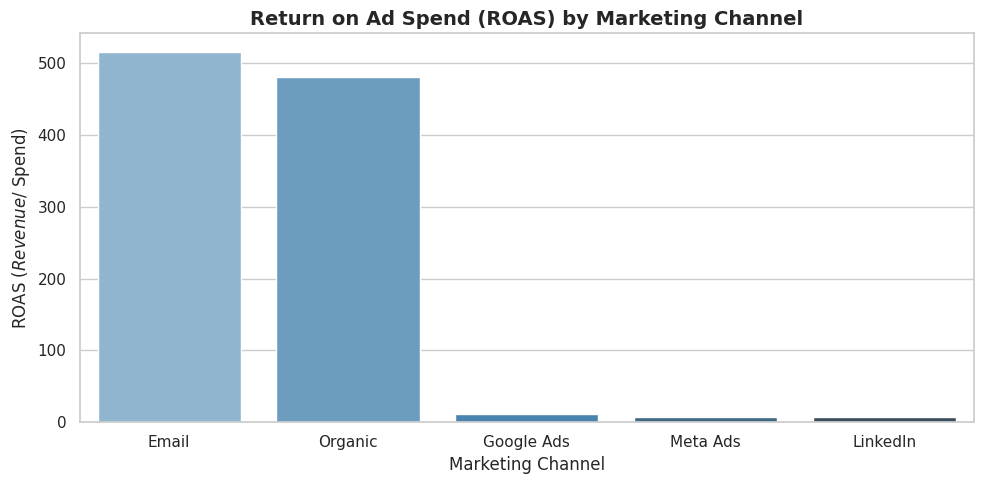

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('marketing_campaign_data.csv')

# Aggregate key metrics by channel
channel_perf = df.groupby('channel').agg({
    'spend': 'sum',
    'revenue': 'sum',
    'impressions': 'sum',
    'clicks': 'sum',
    'conversions': 'sum'
}).reset_index()

# Calculate Marketing KPIs
channel_perf['ROAS'] = (channel_perf['revenue'] / channel_perf['spend']).round(2)
channel_perf['CTR_%'] = ((channel_perf['clicks'] / channel_perf['impressions']) * 100).round(2)
channel_perf['CPA'] = (channel_perf['spend'] / channel_perf['conversions']).round(2)

print("=== Channel Performance Summary ===")
print(channel_perf.sort_values(by='ROAS', ascending=False).to_string(index=False))

# Plot ROAS by Channel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(data=channel_perf.sort_values(by='ROAS', ascending=False), x='channel', y='ROAS', palette='Blues_d')
plt.title('Return on Ad Spend (ROAS) by Marketing Channel', fontsize=14, fontweight='bold')
plt.xlabel('Marketing Channel')
plt.ylabel('ROAS ($ Revenue / $ Spend)')
plt.tight_layout()
plt.savefig('roas_by_channel.png')
plt.show()